This notebook is used for the processing the data and verifying the data.

## Importing required libraries

In [1]:
import numpy as np
import scipy as sp
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


### Loading dataset

In [2]:
df = pd.read_csv('../data/raw.csv')
df.head()

,Customer ID,Gender,Age,Under 30,Senior Citizen,Married,Dependents,Number of Dependents,Country,State,...,Total Extra Data Charges,Total Long Distance Charges,Total Revenue,Satisfaction Score,Customer Status,Churn Label,Churn Score,CLTV,Churn Category,Churn Reason
0,8779-QRDMV,Male,78,No,Yes,No,No,0,United States,California,...,20,0.00,59.65,3,Churned,Yes,91,5433,Competitor,Competitor offered more data
1,7495-OOKFY,Female,74,No,Yes,Yes,Yes,1,United States,California,...,0,390.80,1024.10,3,Churned,Yes,69,5302,Competitor,Competitor made better offer
2,1658-BYGOY,Male,71,No,Yes,No,Yes,3,United States,California,...,0,203.94,1910.88,2,Churned,Yes,81,3179,Competitor,Competitor made better offer
3,4598-XLKNJ,Female,78,No,Yes,Yes,Yes,1,United States,California,...,0,494.00,2995.07,2,Churned,Yes,88,5337,Dissatisfaction,Limited range of services
4,4846-WHAFZ,Female,80,No,Yes,Yes,Yes,1,United States,California,...,0,234.21,3102.36,2,Churned,Yes,67,2793,Price,Extra data charges


### Handling missing values

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 50 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Customer ID                        7043 non-null   object 
 1   Gender                             7043 non-null   object 
 2   Age                                7043 non-null   int64  
 3   Under 30                           7043 non-null   object 
 4   Senior Citizen                     7043 non-null   object 
 5   Married                            7043 non-null   object 
 6   Dependents                         7043 non-null   object 
 7   Number of Dependents               7043 non-null   int64  
 8   Country                            7043 non-null   object 
 9   State                              7043 non-null   object 
 10  City                               7043 non-null   object 
 11  Zip Code                           7043 non-null   int64

In [4]:
df.isna().sum()

Customer ID                             0
Gender                                  0
Age                                     0
Under 30                                0
Senior Citizen                          0
Married                                 0
Dependents                              0
Number of Dependents                    0
Country                                 0
State                                   0
City                                    0
Zip Code                                0
Latitude                                0
Longitude                               0
Population                              0
Quarter                                 0
Referred a Friend                       0
Number of Referrals                     0
Tenure in Months                        0
Offer                                3877
Phone Service                           0
Avg Monthly Long Distance Charges       0
Multiple Lines                          0
Internet Service                  

In [5]:
df['Offer'].head()

0        NaN
1    Offer E
2    Offer D
3    Offer C
4    Offer C
Name: Offer, dtype: object

In [6]:
df.loc[df['Offer'].isna(), 'Offer'] = 'No'

In [7]:
df['Offer'].isna().sum()

0

In [8]:
df['Internet Type'].unique()

array(['DSL', 'Fiber Optic', 'Cable', nan], dtype=object)

In [9]:
df['Internet Type'].value_counts(normalize=True)

Internet Type
Fiber Optic    0.550118
DSL            0.299438
Cable          0.150444
Name: proportion, dtype: float64

In [10]:
df['Internet Type'].fillna('None', inplace=True)

In [11]:
df.drop(['Churn Category', 'Churn Reason'], axis=1, inplace=True)

## Univariate Analysis

In [12]:
df['Gender'].value_counts()

Gender
Male      3555
Female    3488
Name: count, dtype: int64

Text(0.5, 1.0, 'Distribution of Gender')

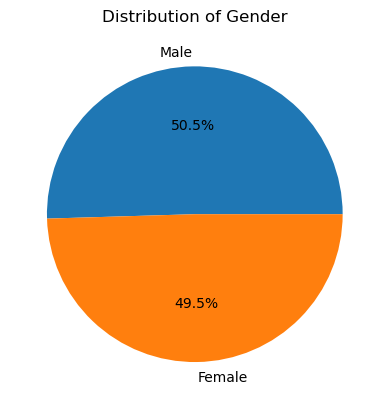

In [13]:
plt.pie(df['Gender'].value_counts(), labels=['Male', 'Female'], autopct="%1.1f%%")
plt.title('Distribution of Gender')

Text(0.5, 1.0, 'Distribution of Age')

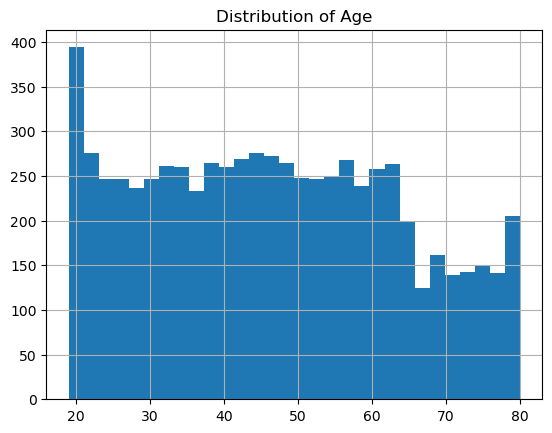

In [14]:
df['Age'].hist(bins=30)
plt.title('Distribution of Age')


Text(0.5, 1.0, 'Distribution of Under 30')

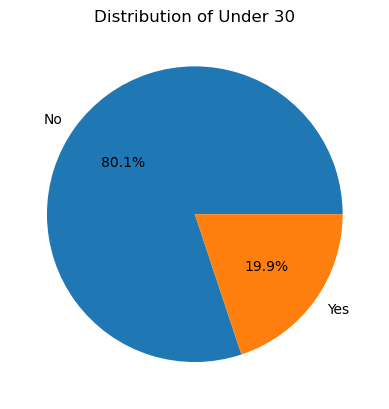

In [15]:
plt.pie(df['Under 30'].value_counts(), labels=['No', 'Yes'], autopct="%1.1f%%")
plt.title('Distribution of Under 30')

Text(0.5, 1.0, 'Distribution of Senior Citizens')

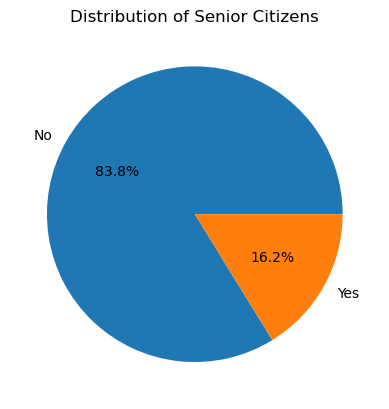

In [16]:
plt.pie(df['Senior Citizen'].value_counts(), labels=['No', 'Yes'], autopct='%1.1f%%')
plt.title('Distribution of Senior Citizens')

Text(0.5, 1.0, 'Distribution of Married')

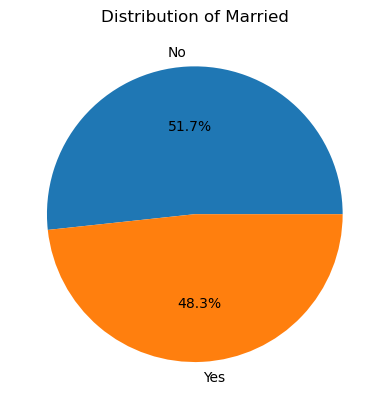

In [17]:
plt.pie(df['Married'].value_counts(), labels=['No', 'Yes'], autopct='%1.1f%%')
plt.title('Distribution of Married')

Text(0.5, 1.0, 'Distribution of Dependents')

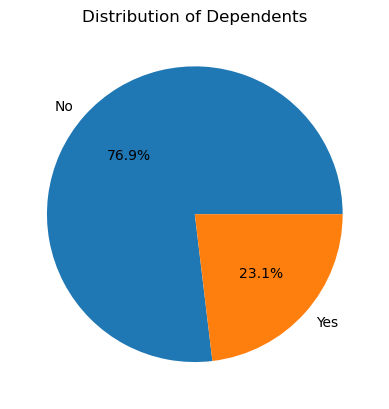

In [18]:
plt.pie(df['Dependents'].value_counts(), labels=['No', 'Yes'], autopct='%1.1f%%')
plt.title('Distribution of Dependents')

Text(0.5, 1.0, 'Distribution of Number of Dependents')

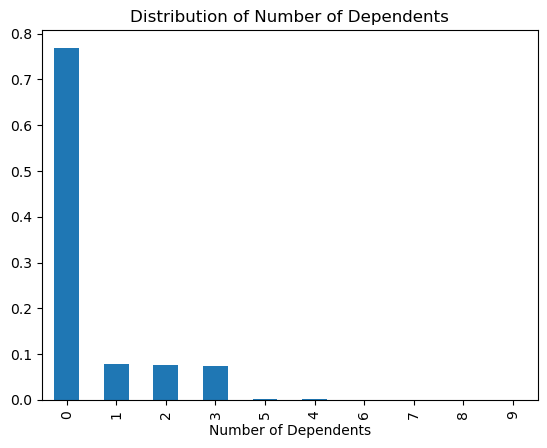

In [19]:
df['Number of Dependents'].value_counts(normalize=True).reset_index()
df['Number of Dependents'].value_counts(normalize=True).plot(kind='bar')
plt.title('Distribution of Number of Dependents')

Text(0.5, 1.0, 'Distribution of City')

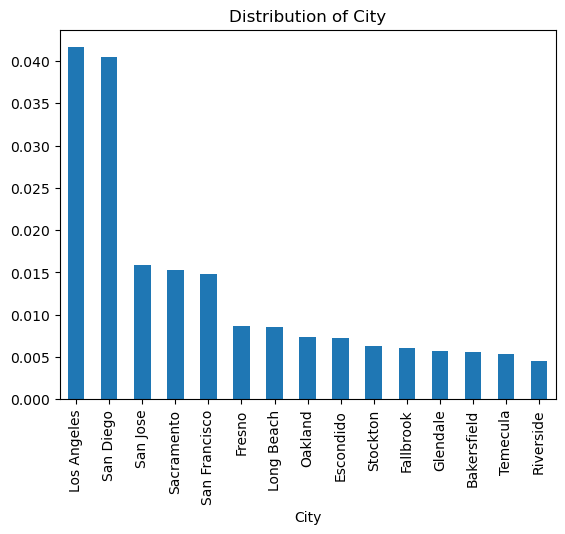

In [20]:
df['City'].value_counts(normalize=True).head(15).plot(kind='bar')
plt.title('Distribution of City')

Text(0.5, 1.0, 'Distribution of Population')

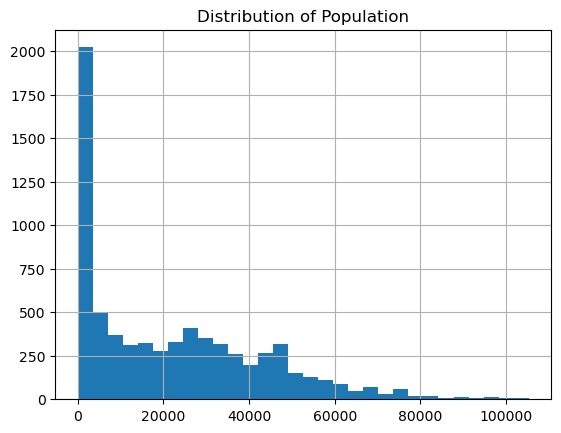

In [21]:
df['Population'].hist(bins=30)
plt.title('Distribution of Population')

Text(0.5, 1.0, 'Distribution of Referred a Friend')

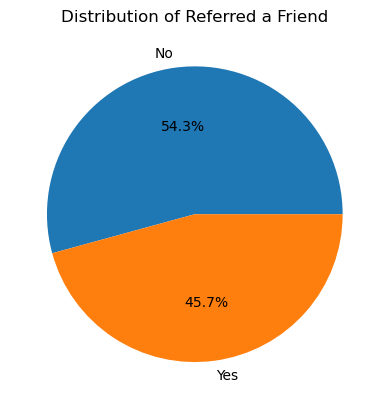

In [22]:
plt.pie(df['Referred a Friend'].value_counts(normalize=True), labels=['No', 'Yes'], autopct='%1.1f%%')
plt.title('Distribution of Referred a Friend')

Text(0.5, 1.0, 'Distribution of Number of Referrals')

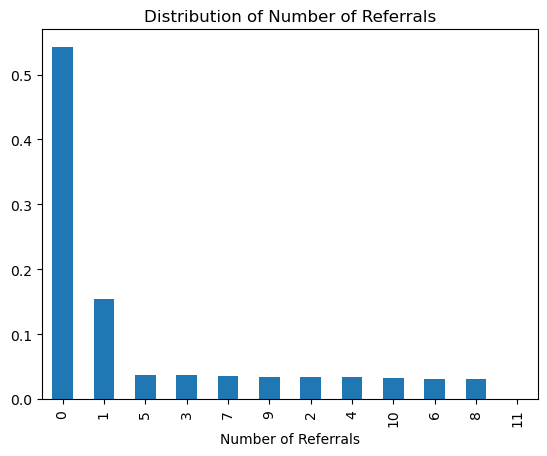

In [23]:
df['Number of Referrals'].value_counts(normalize=True).plot(kind='bar')
plt.title('Distribution of Number of Referrals')

In [24]:
df['Tenure in Months'].describe()

count    7043.000000
mean       32.386767
std        24.542061
min         1.000000
25%         9.000000
50%        29.000000
75%        55.000000
max        72.000000
Name: Tenure in Months, dtype: float64

Text(0.5, 1.0, 'Distribution of Tenure in Months')

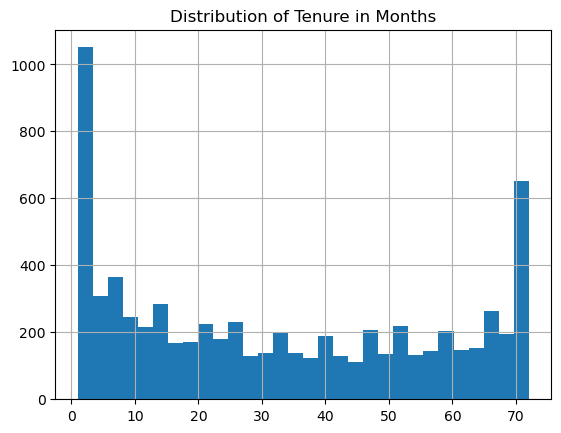

In [25]:
df['Tenure in Months'].hist(bins=30)
plt.title('Distribution of Tenure in Months')

Text(0.5, 1.0, 'Distribution of Offer')

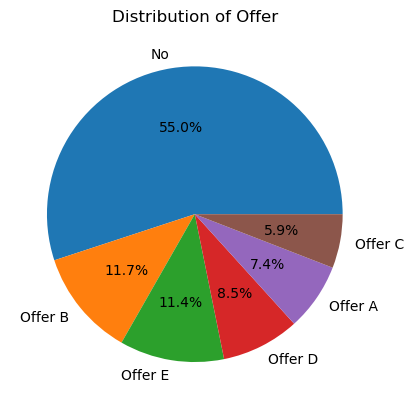

In [26]:
plt.pie(df['Offer'].value_counts(normalize=True), labels=['No', 'Offer B', 'Offer E', 'Offer D', 'Offer A', 'Offer C'], autopct='%1.1f%%')
plt.title('Distribution of Offer')

Text(0.5, 1.0, 'Distribution of Monthly Charge')

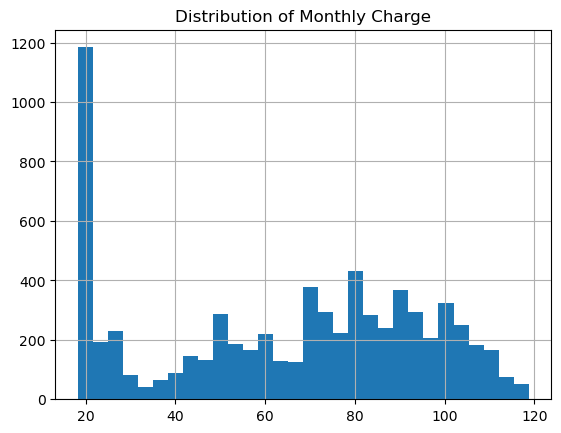

In [27]:
df['Monthly Charge'].hist(bins=30)
plt.title('Distribution of Monthly Charge')

Text(0.5, 1.0, 'Distribution of Contract')

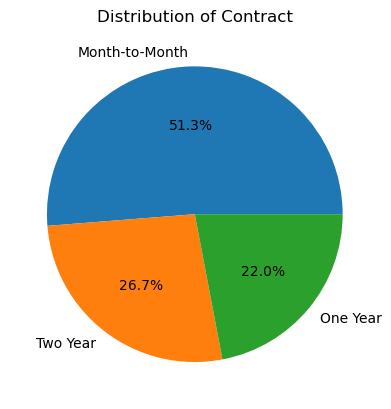

In [28]:
plt.pie(df['Contract'].value_counts(normalize=True), labels=['Month-to-Month', 'Two Year', 'One Year'], autopct='%1.1f%%')
plt.title('Distribution of Contract')

Text(0.5, 1.0, 'Distribution of Internet Service')

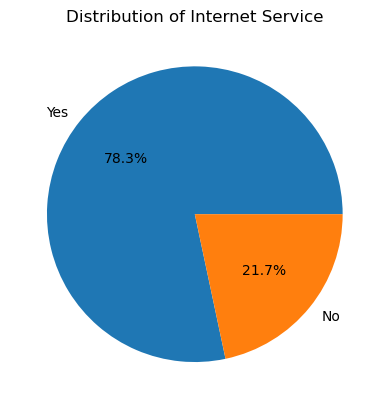

In [29]:
plt.pie(df['Internet Service'].value_counts(normalize=True), labels=['Yes', 'No'], autopct='%1.1f%%')
plt.title('Distribution of Internet Service')

Text(0.5, 1.0, 'Distribution of Internet Type')

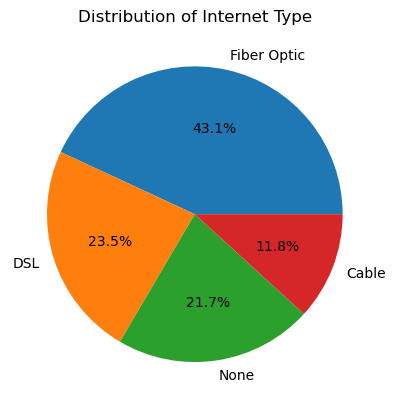

In [30]:
plt.pie(df['Internet Type'].value_counts(normalize=True), labels=['Fiber Optic', 'DSL', 'None', 'Cable'], autopct='%1.1f%%')
plt.title('Distribution of Internet Type')

In [31]:
df['Avg Monthly GB Download'].describe()

count    7043.000000
mean       20.515405
std        20.418940
min         0.000000
25%         3.000000
50%        17.000000
75%        27.000000
max        85.000000
Name: Avg Monthly GB Download, dtype: float64

Text(0.5, 1.0, 'Distribution of Average Monthly Download (GB)')

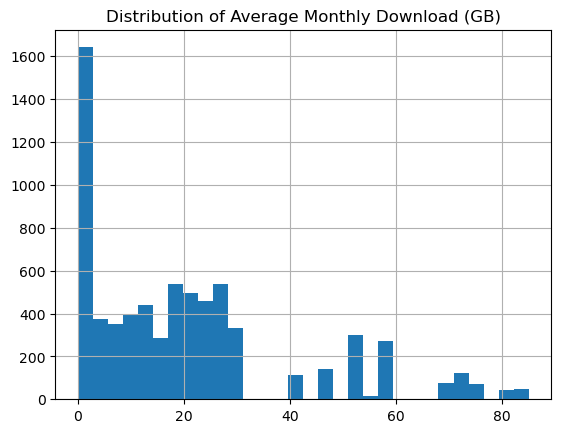

In [32]:
df['Avg Monthly GB Download'].hist(bins=30)
plt.title('Distribution of Average Monthly Download (GB)')

Text(0.5, 1.0, 'Distribution of Payment Methods')

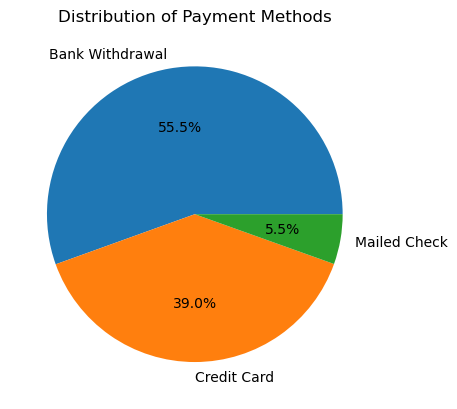

In [33]:
plt.pie(df['Payment Method'].value_counts(normalize=True), labels=['Bank Withdrawal', 'Credit Card', 'Mailed Check'], autopct='%1.1f%%')
plt.title('Distribution of Payment Methods')

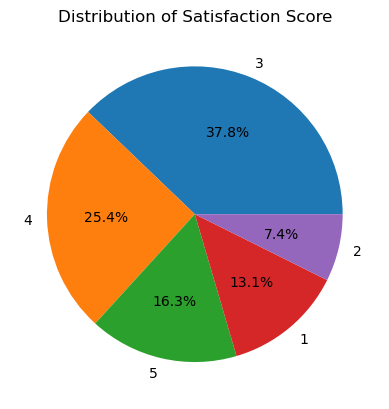

Satisfaction Score
3    0.378390
4    0.254011
5    0.163141
1    0.130910
2    0.073548
Name: proportion, dtype: float64

In [34]:
plt.pie(df['Satisfaction Score'].value_counts(normalize=True), labels=['3', '4', '5', '1', '2'], autopct='%1.1f%%')
plt.title('Distribution of Satisfaction Score')
plt.show()
df['Satisfaction Score'].value_counts(normalize=True)

## Bivariate Analysis

In [35]:
pd.crosstab(df['Contract'], df['Churn Label'], normalize='index').round(4)*100

Churn Label,No,Yes
Contract,,
Month-to-Month,54.16,45.84
One Year,89.29,10.71
Two Year,97.45,2.55


In [36]:
df.groupby('Churn Label')['Tenure in Months'].mean().reset_index()

,Churn Label,Tenure in Months
0,No,37.591225
1,Yes,17.979133


<Axes: xlabel='Churn Label', ylabel='Tenure in Months'>

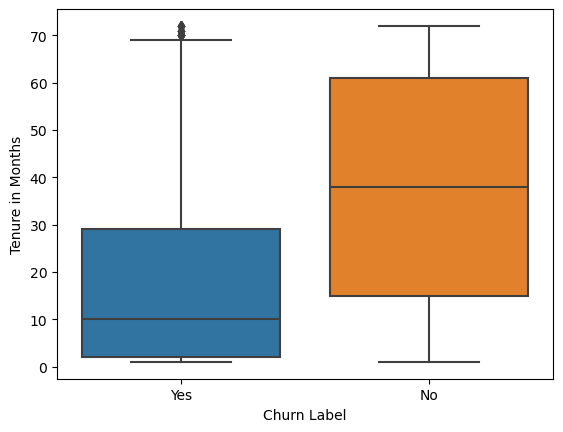

In [37]:
sns.boxplot(x='Churn Label', y='Tenure in Months', data=df)

<Axes: xlabel='Churn Label', ylabel='Monthly Charge'>

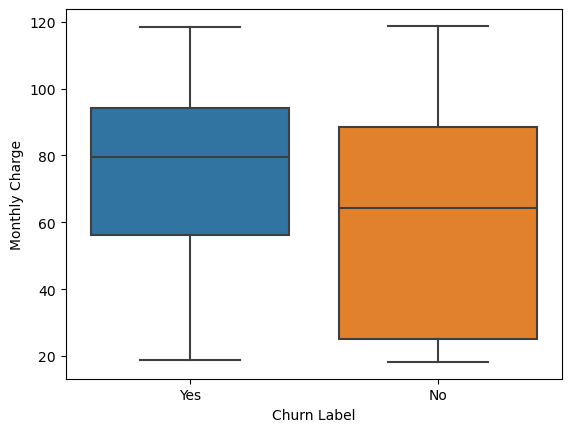

In [38]:
sns.boxplot(x='Churn Label', y='Monthly Charge', data=df)

In [39]:
pd.crosstab(df['Payment Method'], df['Churn Label'], normalize='index').round(4)*100

Churn Label,No,Yes
Payment Method,,
Bank Withdrawal,66.00,34.00
Credit Card,85.52,14.48
Mailed Check,63.12,36.88


In [40]:
df.groupby('Churn Label')['Age'].mean().reset_index()

,Churn Label,Age
0,No,45.344414
1,Yes,49.735688


In [41]:
pd.crosstab(df['Married'], df['Churn Label'], normalize='index').round(4)*100

Churn Label,No,Yes
Married,,
No,67.04,32.96
Yes,80.34,19.66


In [42]:
pd.crosstab(df['Gender'], df['Churn Label'], normalize='index').round(4)*100

Churn Label,No,Yes
Gender,,
Female,73.08,26.92
Male,73.84,26.16


In [43]:
pd.crosstab(df['Referred a Friend'], df['Churn Label'], normalize='index').round(4)*100

Churn Label,No,Yes
Referred a Friend,,
No,67.42,32.58
Yes,80.63,19.37


In [44]:
pd.crosstab(df['Multiple Lines'], df['Churn Label'], normalize='index').round(4)*100

Churn Label,No,Yes
Multiple Lines,,
No,74.98,25.02
Yes,71.39,28.61


In [45]:
pd.crosstab(df['Offer'], df['Churn Label'], normalize='index').round(4)*100

Churn Label,No,Yes
Offer,,
No,72.89,27.11
Offer A,93.27,6.73
Offer B,87.74,12.26
Offer C,77.11,22.89
Offer D,73.26,26.74
Offer E,47.08,52.92


In [47]:
df.to_csv('../data/processed.csv')